In [ ]:
# Logistic Regression - Wine Quality Prediction
This notebook implements Logistic Regression for wine quality classification.


In [3]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [6]:
# -------------------------------
# LOAD DATA

red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')
df = pd.concat([red, white])

# Convert to binary classification
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# Features & target
X = df.drop('quality', axis=1)
y = df['quality']

In [7]:
# -------------------------------
# FEATURE SCALING (IMPORTANT for LR)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# -------------------------------
# TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:
# -------------------------------
# MODEL TRAINING
# -------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
# -------------------------------
# PREDICTION
# -------------------------------
pred = model.predict(X_test)

In [12]:
# -------------------------------
# EVALUATION
# -------------------------------
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


Accuracy: 0.7238461538461538

Confusion Matrix:
 [[262 189]
 [170 679]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.58      0.59       451
           1       0.78      0.80      0.79       849

    accuracy                           0.72      1300
   macro avg       0.69      0.69      0.69      1300
weighted avg       0.72      0.72      0.72      1300



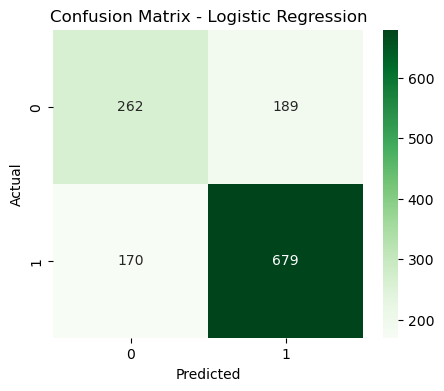

In [13]:
# -------------------------------
# CONFUSION MATRIX VISUALIZATION
# -------------------------------
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

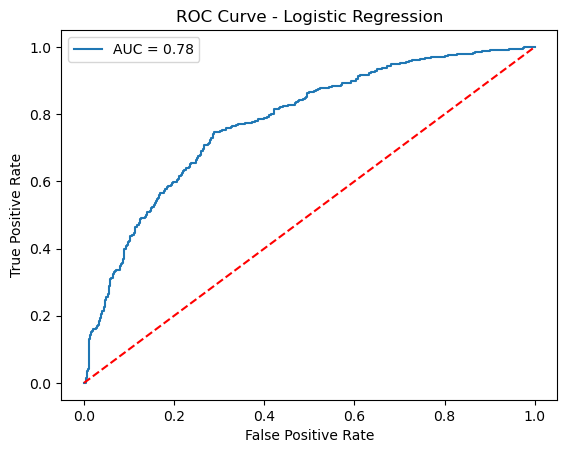

In [14]:
# -------------------------------
# ROC CURVE
# -------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [15]:
# -------------------------------
# CROSS VALIDATION
# -------------------------------
scores = cross_val_score(model, X_scaled, y, cv=5)

print("\nCross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


Cross Validation Scores: [0.51153846 0.66769231 0.71747498 0.7382602  0.72055427]
Average Accuracy: 0.6711040445312964


In [16]:
# -------------------------------
# SAVE RESULTS
# -------------------------------
pd.DataFrame({
    'Algorithm': ['Logistic Regression'],
    'Accuracy': [acc]
}).to_csv("logistic_regression.csv", index=False)

In [18]:
# -------------------------------
# CONCLUSION (PRINT)
# -------------------------------
print("\nModel evaluation completed successfully.")
print("Logistic Regression provides a simple and interpretable baseline model.")


Model evaluation completed successfully.
Logistic Regression provides a simple and interpretable baseline model.
